In [1]:
! pip install idx2numpy

  Preparing metadata (setup.py) ... done
  Created wheel for idx2numpy: filename=idx2numpy-1.2.3-py3-none-any.whl size=7903 sha256=95a476336299bf90e6bb1362646f54144b77f0d12cb70de4a4b06fb8536dbb0c
  Stored in directory: /root/.cache/pip/wheels/f7/48/00/ae031c97d62f39e1c3c4daa00426c09a65eb29ae5753a189ee
Successfully built idx2numpy


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import math
import idx2numpy
import kagglehub

In [3]:
# Download latest version
path = kagglehub.dataset_download("hojjatk/mnist-dataset")
print("Path to dataset files:", path)

gen = Path(path).iterdir()
data = dict()
for i in gen:
    if i.is_file():
        data[i.stem] = idx2numpy.convert_from_file(str(i))

train_labels = data["train-labels"]

100%|██████████| 22.0M/22.0M [00:00<00:00, 92.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/hojjatk/mnist-dataset/versions/1


In [4]:
def add_bias(array):
    ones_array = np.ones(array.shape[0])[:, None]
    return np.concatenate([ones_array, array], axis=1)

def leaky_relu(x):
  return np.where(x>0,x,0.01*x)

def derivative_leaky(x):
    return np.where(x>0,1,0.01)

def generate_theta(current_neurons, next_neurons, seed):
    rng = np.random.default_rng(seed)
    thetas = rng.standard_normal((current_neurons, next_neurons)) * 0.01
    return thetas

def softmax(score, temp=1):
    positive_exp = np.exp(score / temp)
    summation = np.sum(positive_exp, axis=1)[:, None]
    return positive_exp / summation

In [5]:
train_image = add_bias((data['train-images'] / 255.0).reshape(-1, 784))

theta_hidden1= generate_theta(785, 64, 22)
theta_hidden2= generate_theta (65,64,3)
theta_output = generate_theta(65, 10, 12)

one_hot_encoding = np.zeros((train_image.shape[0],theta_output.shape[1]))
one_hot_encoding[range(one_hot_encoding.shape[0]), train_labels] = 1


In [6]:
def forward_pass(images,theta_hidden1,theta_hiden2,theta_output):
    hidden1 = leaky_relu(np.dot(images, theta_hidden1))

    bias_hidden1=add_bias(hidden1)

    hidden2=leaky_relu(np.dot(bias_hidden1, theta_hidden2))

    bias_hidden2=add_bias(hidden2)

    softmax_output = softmax(np.dot(bias_hidden2, theta_output))

    return hidden1,bias_hidden1,hidden2,bias_hidden2,softmax_output

In [7]:
learning=0.01
epoch=340
for i in range(epoch):

  for batch in range(60):

    batch_data=train_image[batch*1000:(batch+1)*1000]

    hidden1,bias_hidden1,hidden2,bias_hidden2,softmax_output=forward_pass(batch_data,theta_hidden1,theta_hidden2,theta_output)

    #------------------------------------------------------------------#
    # hidden layers deruvatives

    leaky1_derivate = derivative_leaky(hidden1)
    leaky2_derivate = derivative_leaky(hidden2)

    # Calculate Errors

    output_error = softmax_output - one_hot_encoding[batch*1000:(batch+1)*1000]

    hidden2_error = (output_error @ theta_output[1:].T) * leaky2_derivate

    hidden1_error= (hidden2_error @ theta_hidden2[1:].T) * leaky1_derivate

    # Calculate Gradient
    batch_size=batch_data.shape[0]

    output_gradient=(bias_hidden2.T @ output_error)/batch_size
    hidden2_gradient=(bias_hidden1.T @ hidden2_error)/batch_size
    hidden1_gradient=(batch_data.T @ hidden1_error)/batch_size

    theta_output-=learning*output_gradient
    theta_hidden2-=learning*hidden2_gradient
    theta_hidden1-=learning*hidden1_gradient


  print(f"iteration: {i} , mean of loss {np.mean(-np.log(softmax_output[range(1_000),train_labels[batch*1000:(batch+1)*1000]]))}")



Streaming output truncated to the last 5000 lines.
iteration: 256 , mean of loss 0.25126410715869146
iteration: 256 , mean of loss 0.31828648486201444
iteration: 256 , mean of loss 0.3461083886891682
iteration: 256 , mean of loss 0.2577478145023988
iteration: 256 , mean of loss 0.26030085137495534
iteration: 256 , mean of loss 0.318674095835703
iteration: 256 , mean of loss 0.27600046601286893
iteration: 256 , mean of loss 0.29012107029436485
iteration: 256 , mean of loss 0.22683451283211123
iteration: 256 , mean of loss 0.3594964432740071
iteration: 256 , mean of loss 0.34426593460384347
iteration: 256 , mean of loss 0.22992569475633298
iteration: 256 , mean of loss 0.33874555108324206
iteration: 256 , mean of loss 0.28008445166416834
iteration: 256 , mean of loss 0.28022493463564424
iteration: 256 , mean of loss 0.23345359698318957
iteration: 256 , mean of loss 0.2307145558292683
iteration: 256 , mean of loss 0.24664472572561447
iteration: 256 , mean of loss 0.16208151445506458
itera

In [22]:
test_images=data['t10k-images']
test_labels=data['t10k-labels']

In [23]:
_,_,_,_,softmax_output=forward_pass(add_bias(test_images.reshape(-1,784)/255.0),theta_hidden1,theta_hidden2,theta_output)

In [24]:
predictions=np.argmax(softmax_output,axis=1)

In [11]:
def  confusion_matrix(truelabel,predictedlabel):
  l=[]
  y,x=np.meshgrid(range(10),range(10))
  for i,j in zip(x.flatten(),y.flatten()):
   l.append(( (truelabel==i) & (predictedlabel==j) ).sum())
  return np.array(l).reshape(10,10)



In [12]:
matrix=confusion_matrix(test_labels,predictions)

In [13]:

tp=np.diag(matrix)
fn = matrix.sum(axis=1) - tp
fp= matrix.sum(axis=0) - tp
tn=10_000 - tp - fn - fp



In [14]:
def accuracy(tp,tn,fp,fn):
  return (tp+tn)/(tp+tn+fp+fn)

def recall(tp,fn):
  return tp/(tp+fn)

def precision(tp,fp):
  return tp/(tp+fp)

def f1score(recall,precision):
  return 2* ((recall*precision)/(recall+precision))

In [15]:
macro_acc=np.mean(accuracy(tp,tn,fp,fn))
macro_re=np.mean(recall(tp,fn))
macro_pre=np.mean(precision(tp,fp))



In [16]:
macro_acc

np.float64(0.9881800000000001)

In [17]:
macro_re

np.float64(0.9401721672883954)

In [18]:
macro_pre

np.float64(0.9402266261388588)

In [19]:
macro_f1score = f1score(macro_re,macro_pre)
macro_f1score

np.float64(0.9401993959250267)

In [20]:
overall_acc=np.diag(matrix).sum()/10_000
overall_acc

np.float64(0.9409)

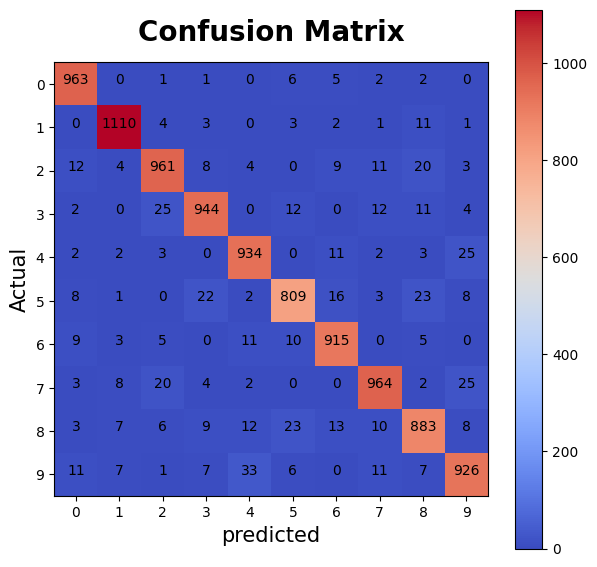

In [21]:
#Create Heatmap
fig,ax=plt.subplots(figsize=(7,7),)
obj=ax.imshow(matrix,cmap="coolwarm")
fig.colorbar(obj)

ax.set_title("Confusion Matrix",y=1.03,size=20,fontweight=1000)
ax.set_ylabel("Actual",size=15)
ax.set_xlabel("predicted",size=15)

ax.set_xticks([0,1,2,3,4,5,6,7,8,9])
ax.set_yticks([0,1,2,3,4,5,6,7,8,9])

# assign values to the box

for i in range(10):
  for j in range(10):
    ax.text(j,i,f"{matrix[i,j]}",ha="center")

plt.show()